In [45]:
!pip install linearmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, PooledOLS
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Penn World Tables 11.0 — GDP per capita and controls
pwt = pd.read_excel('pwt110.xlsx', sheet_name='Data')

# Target countries and their ISO3 codes
country_map = {
    'PAK': 'Pakistan',
    'IND': 'India',
    'BGD': 'Bangladesh',
    'VNM': 'Vietnam',
    'THA': 'Thailand',
    'MMR': 'Myanmar',
    'TWN': 'Taiwan',
    'JPN': 'Japan',
    'KOR': 'South Korea',
}

pwt_f = pwt[
    (pwt['countrycode'].isin(country_map.keys())) &
    (pwt['year'].between(2000, 2023))
].copy()

# GDP per capita: rgdpe (millions 2017 USD PPP) / pop (millions) = USD PPP per person
pwt_f['gdp_pc']    = pwt_f['rgdpe'] / pwt_f['pop']
pwt_f['ln_gdp_pc'] = np.log(pwt_f['gdp_pc'])

# Trade openness: exports share + abs(imports share)
pwt_f['trade']   = pwt_f['csh_x'] + pwt_f['csh_m'].abs()

# Gross capital formation share of GDP
pwt_f['capform'] = pwt_f['csh_i']

pwt_clean = pwt_f[['countrycode','year','ln_gdp_pc','gdp_pc','hc','trade','capform','pop']].copy()
pwt_clean = pwt_clean.rename(columns={'countrycode': 'iso3'})

print(f"PWT rows: {len(pwt_clean)}")
print(f"Countries: {pwt_clean['iso3'].nunique()}, Years: {pwt_clean['year'].nunique()}")
print("\nMissing values:")
print(pwt_clean.isnull().sum())
pwt_clean.head()

PWT rows: 216
Countries: 9, Years: 24

Missing values:
iso3         0
year         0
ln_gdp_pc    0
gdp_pc       0
hc           0
trade        0
capform      0
pop          0
dtype: int64


,iso3,year,ln_gdp_pc,gdp_pc,hc,trade,capform,pop
1160,BGD,2000,7.349734,1555.782835,1.639889,0.150221,0.207404,134.544304
1161,BGD,2001,7.358022,1568.730318,1.661910,0.157399,0.210769,136.805810
1162,BGD,2002,7.383912,1609.875489,1.684226,0.160139,0.214708,138.933658
1163,BGD,2003,7.399958,1635.915249,1.706841,0.163637,0.218853,140.970351
1164,BGD,2004,7.417470,1664.815397,1.724663,0.177964,0.227815,142.902856


In [47]:
# Internet CSV loader (supports ITU long format OR WDI wide format)
with open('internet_ds/internet.csv', 'r', encoding='utf-8-sig', errors='replace') as f:
    lines = f.readlines()

# Try ITU long-format header first
header_idx_long = next(
    (i for i, line in enumerate(lines) if 'entityIso' in line and 'dataYear' in line and 'dataValue' in line),
    None
)

# Try WDI wide-format header as fallback
header_idx_wdi = next(
    (i for i, line in enumerate(lines) if 'Country Name' in line and 'Country Code' in line and 'Indicator Code' in line),
    None
)

if header_idx_long is not None:
    # --- ITU long format ---
    internet_raw = pd.read_csv(
        'internet_ds/internet.csv',
        encoding='utf-8-sig',
        skiprows=header_idx_long,
        engine='python',
        on_bad_lines='skip'
    )
    internet_raw.columns = internet_raw.columns.str.strip()

    required_cols = {'entityIso', 'dataYear', 'dataValue'}
    missing_cols = required_cols - set(internet_raw.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns after loading CSV: {sorted(missing_cols)}")

    internet = internet_raw[
        (internet_raw['entityIso'].isin(country_map.keys())) &
        (internet_raw['dataYear'].between(2000, 2020))
    ].copy()

    internet['dataValue'] = pd.to_numeric(internet['dataValue'], errors='coerce')

    internet_clean = internet[['entityIso', 'dataYear', 'dataValue']].rename(columns={
        'entityIso': 'iso3',
        'dataYear': 'year',
        'dataValue': 'internet_pct'
    })

else:
    # --- WDI wide format (your current file) ---
    if header_idx_wdi is None:
        raise ValueError("Could not detect a valid header row for either ITU long format or WDI wide format.")

    internet_raw = pd.read_csv(
        'internet_ds/internet.csv',
        encoding='utf-8-sig',
        skiprows=header_idx_wdi
    )
    internet_raw.columns = internet_raw.columns.str.strip()

    required_cols = {'Country Code'}
    missing_cols = required_cols - set(internet_raw.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns after loading CSV: {sorted(missing_cols)}")

    year_cols = [c for c in internet_raw.columns if str(c).isdigit() and 2000 <= int(c) <= 2020]
    if not year_cols:
        raise ValueError("No year columns (2000–2020) found in WDI file.")

    internet = internet_raw[internet_raw['Country Code'].isin(country_map.keys())].copy()

    internet_clean = internet.melt(
        id_vars=['Country Code'],
        value_vars=year_cols,
        var_name='year',
        value_name='internet_pct'
    ).rename(columns={'Country Code': 'iso3'})

    internet_clean['year'] = internet_clean['year'].astype(int)
    internet_clean['internet_pct'] = pd.to_numeric(internet_clean['internet_pct'], errors='coerce')

print(f"\nInternet rows: {len(internet_clean)}")
print(f"Countries found: {internet_clean['iso3'].nunique()}")
print("Countries:", sorted(internet_clean['iso3'].unique()))
print("\nMissing values:", internet_clean.isnull().sum().to_dict())
internet_clean.head()


Internet rows: 168
Countries found: 8
Countries: ['BGD', 'IND', 'JPN', 'KOR', 'MMR', 'PAK', 'THA', 'VNM']

Missing values: {'iso3': 0, 'year': 0, 'internet_pct': 2}


,iso3,year,internet_pct
0,BGD,2000,0.071039
1,IND,2000,0.527532
2,JPN,2000,29.990700
3,KOR,2000,44.700000
4,MMR,2000,NaN


In [48]:
# Merge PWT + ITU on country-year
df = pd.merge(pwt_clean, internet_clean, on=['iso3','year'], how='inner')

# 3-level development status
developed_isos = ['TWN', 'JPN', 'KOR']
least_developed_isos = ['MMR', 'BGD']

df['developed'] = 'developing'
df.loc[df['iso3'].isin(developed_isos), 'developed'] = 'developed'
df.loc[df['iso3'].isin(least_developed_isos), 'developed'] = 'least developed'
df['developed'] = pd.Categorical(
    df['developed'],
    categories=['least developed', 'developing', 'developed'],
    ordered=True
)

# Keep a binary developed indicator for interaction terms in regressions
df['is_developed'] = (df['developed'] == 'developed').astype(int)

# Add country label for plotting
df['country'] = df['iso3'].map(country_map)

# Sort before lagging - essential for correct shift()
df = df.sort_values(['iso3','year']).reset_index(drop=True)

# Lagged internet (t-1): addresses reverse causality
df['internet_lag1'] = df.groupby('iso3')['internet_pct'].shift(1)

# Interaction term: lagged internet x developed indicator
df['internet_x_dev'] = df['internet_lag1'] * df['is_developed']

print(f"Final dataset: {df.shape[0]} rows, {df['iso3'].nunique()} countries")
print(f"\nRows per country:")
print(df.groupby('country')['year'].count().sort_values())
print(f"\nDevelopment status by country:")
print(df.groupby(['iso3', 'country'])['developed'].first().sort_values())
print(f"\nMissing values in key variables:")
print(df[['ln_gdp_pc','internet_lag1','hc','trade','capform']].isnull().sum())

Final dataset: 168 rows, 8 countries

Rows per country:
country
Bangladesh     21
India          21
Japan          21
Myanmar        21
Pakistan       21
South Korea    21
Thailand       21
Vietnam        21
Name: year, dtype: int64

Development status by country:
iso3  country    
BGD   Bangladesh     least developed
MMR   Myanmar        least developed
IND   India               developing
PAK   Pakistan            developing
THA   Thailand            developing
VNM   Vietnam             developing
JPN   Japan                developed
KOR   South Korea          developed
Name: developed, dtype: category
Categories (3, object): ['least developed' < 'developing' < 'developed']

Missing values in key variables:
ln_gdp_pc         0
internet_lag1    10
hc                0
trade             0
capform           0
dtype: int64


In [49]:
desc_vars = ['gdp_pc','internet_pct','hc','trade','capform']
desc_labels = {
    'gdp_pc':       'GDP per Capita (USD PPP)',
    'internet_pct': 'Internet Usage (% population)',
    'hc':           'Human Capital Index',
    'trade':        'Trade Openness (share of GDP)',
    'capform':      'Capital Formation (share of GDP)'
}

desc = df[desc_vars].describe().T.round(2)
desc.index = [desc_labels[v] for v in desc_vars]
print("=== Descriptive Statistics ===")
print(desc[['count','mean','std','min','25%','50%','75%','max']].to_string())

=== Descriptive Statistics ===
                                  count      mean       std      min      25%      50%       75%       max
GDP per Capita (USD PPP)          168.0  15061.09  15978.73  1164.89  3876.07  6106.27  22588.63  49920.06
Internet Usage (% population)     166.0     31.71     31.84     0.00     5.01    18.15     57.81     96.51
Human Capital Index               168.0      2.40      0.69     1.52     1.81     2.13      2.89      3.76
Trade Openness (share of GDP)     168.0      0.36      0.25     0.09     0.15     0.28      0.56      1.05
Capital Formation (share of GDP)  168.0      0.25      0.07     0.10     0.21     0.25      0.29      0.39


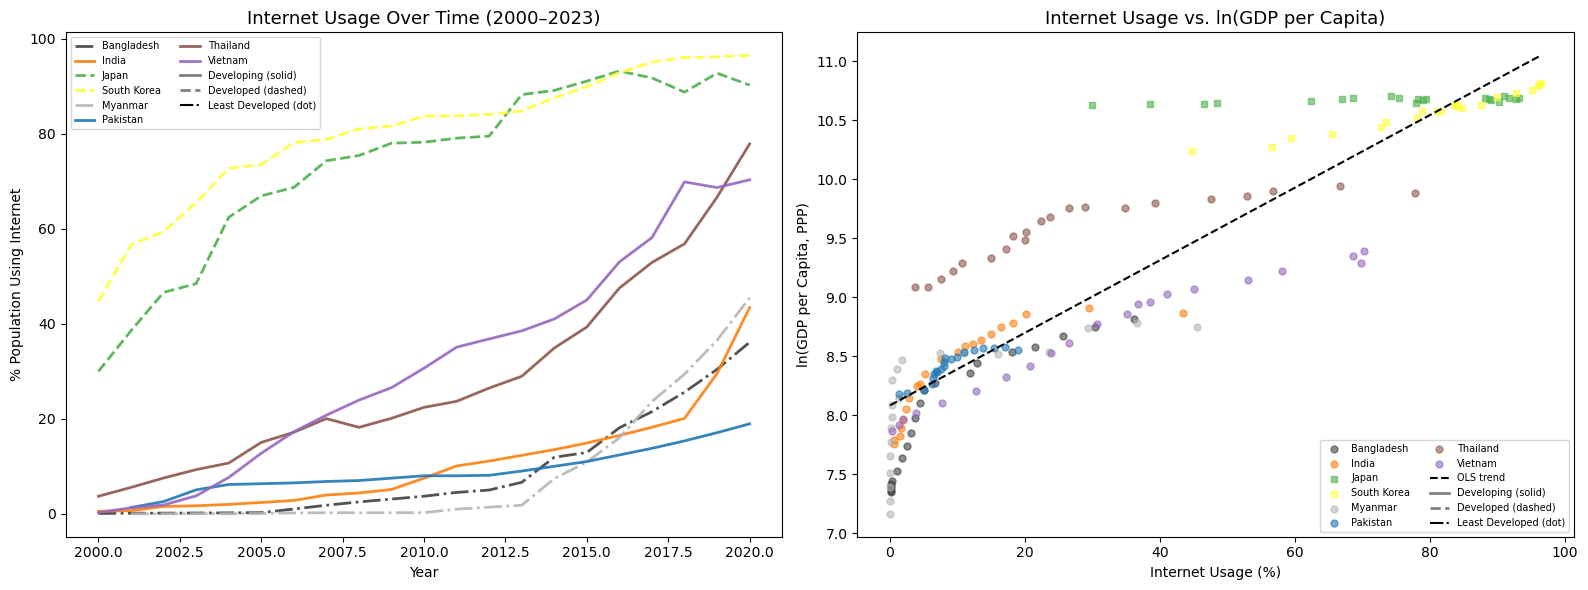

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np

# Unique color per country using two colormaps
developing_isos = ['PAK','IND','PHL','BGD','VNM','THA','IDN','MYS','MMR']
developed_isos  = ['TWN','JPN','KOR',]
least_developed_isos = ['MMR', 'BGD']


dev_colors  = cm.tab10(np.linspace(0, 0.95, len(developing_isos)))
devd_colors = cm.Set1(np.linspace(0, 0.6, len(developed_isos)))
ldev_colors = cm.Greys(np.linspace(0.4, 0.8, len(least_developed_isos)))
color_map = {}
for i, iso in enumerate(developing_isos):
    color_map[iso] = dev_colors[i]
for i, iso in enumerate(developed_isos):
    color_map[iso] = devd_colors[i]
for i, iso in enumerate(least_developed_isos):
    color_map[iso] = ldev_colors[i]

# Line style: solid = developing, dashed = developed
style_map = {iso: '-'  for iso in developing_isos}
style_map.update({iso: '--' for iso in developed_isos})
style_map.update({iso: '-.' for iso in least_developed_isos})
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Internet usage over time ---
for iso, grp in df.groupby('iso3'):
    axes[0].plot(grp['year'], grp['internet_pct'],
                 label=country_map[iso],
                 color=color_map[iso],
                 linestyle=style_map[iso],
                 linewidth=2, alpha=0.9)

axes[0].set_title('Internet Usage Over Time (2000–2023)', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% Population Using Internet')
axes[0].legend(fontsize=7.5, ncol=2, loc='upper left')

# --- Plot 2: Internet vs ln(GDP per Capita) scatter ---
for iso, grp in df.groupby('iso3'):
    axes[1].scatter(grp['internet_pct'], grp['ln_gdp_pc'],
                    label=country_map[iso],
                    color=color_map[iso],
                    marker='o' if iso in developing_isos else 's',
                    alpha=0.6, s=25)

# OLS trendline
valid = df[['internet_pct','ln_gdp_pc']].dropna()
m, b = np.polyfit(valid['internet_pct'], valid['ln_gdp_pc'], 1)
x_line = np.linspace(valid['internet_pct'].min(), valid['internet_pct'].max(), 100)
axes[1].plot(x_line, m*x_line + b, 'k--', linewidth=1.5, label='OLS trend')

axes[1].set_title('Internet Usage vs. ln(GDP per Capita)', fontsize=13)
axes[1].set_xlabel('Internet Usage (%)')
axes[1].set_ylabel('ln(GDP per Capita, PPP)')
axes[1].legend(fontsize=7.5, ncol=2, loc='lower right')

# Shared legend explaining line style / marker convention
legend_elements = [
    Line2D([0],[0], color='gray', linestyle='-',  lw=2, label='Developing (solid / circle)'),
    Line2D([0],[0], color='gray', linestyle='--', lw=2, label='Developed  (dashed / square)'),
    Line2D([0],[0], color='k', linestyle='-.', lw=1.5, label='Least Developed (dashed / dot)'),
]
for ax in axes:
    existing = ax.get_legend()
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + legend_elements,
              labels=labels + ['Developing (solid)', 'Developed (dashed)', 'Least Developed (dot)'],
              fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('eda_internet_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

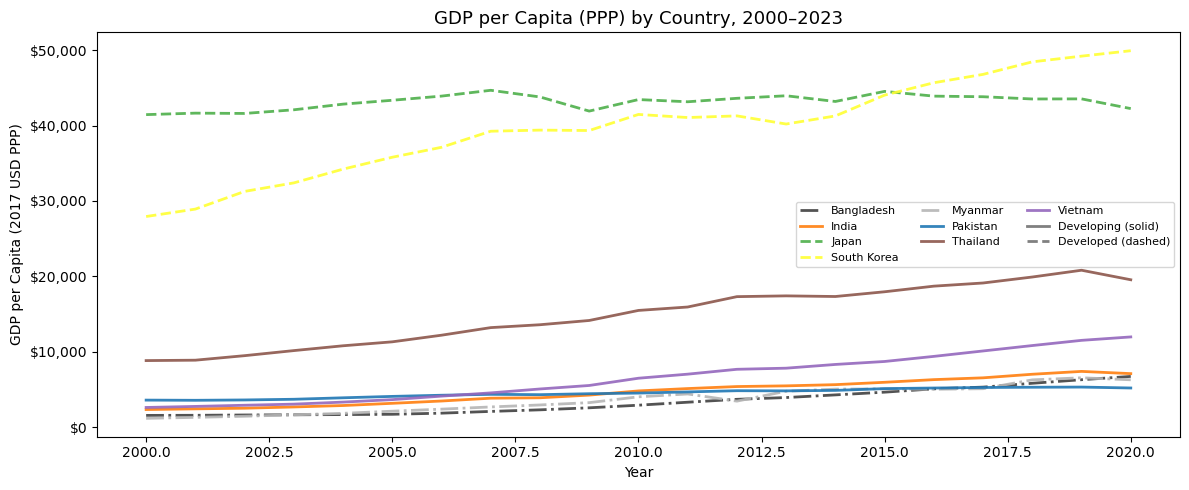

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))

for iso, grp in df.groupby('iso3'):
    ax.plot(grp['year'], grp['gdp_pc'],
            label=country_map[iso],
            color=color_map[iso],
            linestyle=style_map[iso],
            linewidth=2, alpha=0.9)

ax.set_title('GDP per Capita (PPP) by Country, 2000–2023', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (2017 USD PPP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8, ncol=3)

# Convention note
legend_elements = [
    Line2D([0],[0], color='gray', linestyle='-',  lw=2, label='Developing (solid)'),
    Line2D([0],[0], color='gray', linestyle='--', lw=2, label='Developed (dashed)')
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_elements,
          labels=labels + ['Developing (solid)', 'Developed (dashed)'],
          fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig('gdp_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Drop rows missing any key variable
reg_vars = ['ln_gdp_pc','internet_lag1','hc','trade','capform','developed','internet_x_dev']
df_reg = df.dropna(subset=reg_vars).copy()

# Set MultiIndex required by linearmodels (entity, time)
df_reg = df_reg.set_index(['iso3','year'])

print(f"Regression sample: {len(df_reg)} obs, {df_reg.index.get_level_values('iso3').nunique()} countries")
print(f"Year range: {df_reg.index.get_level_values('year').min()}–{df_reg.index.get_level_values('year').max()}")

Regression sample: 158 obs, 8 countries
Year range: 2001–2020


In [53]:
# Pooled OLS ignores panel structure — useful as a naive baseline
X_pool = sm.add_constant(df_reg[['internet_lag1','hc','trade','capform']])
pooled = PooledOLS(df_reg['ln_gdp_pc'], X_pool).fit(cov_type='robust')

print("=" * 60)
print("MODEL 1: POOLED OLS (Baseline — no fixed effects)")
print("=" * 60)
print(pooled.summary)

MODEL 1: POOLED OLS (Baseline — no fixed effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:              ln_gdp_pc   R-squared:                        0.9317
Estimator:                  PooledOLS   R-squared (Between):              0.9674
No. Observations:                 158   R-squared (Within):               0.6194
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.9317
Time:                        11:47:31   Log-likelihood                   -21.628
Cov. Estimator:                Robust                                           
                                        F-statistic:                      521.47
Entities:                           8   P-value                           0.0000
Avg Obs:                       19.750   Distribution:                   F(4,153)
Min Obs:                       19.000                                           
Max Obs:                       20.000   F-statistic (robust

In [54]:
# Country FE (absorbs geography, institutions) + Year FE (absorbs global shocks)
fe_main = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1','hc','trade','capform']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)  # Cluster SEs by country

print("=" * 60)
print("MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)")
print("Clustered SEs by country")
print("=" * 60)
print(fe_main.summary)

MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)
Clustered SEs by country
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.5607
Estimator:                   PanelOLS   R-squared (Between):              0.8459
No. Observations:                 158   R-squared (Within):               0.8437
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.8471
Time:                        11:47:31   Log-likelihood                    112.90
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      40.518
Entities:                           8   P-value                           0.0000
Avg Obs:                       19.750   Distribution:                   F(4,127)
Min Obs:                       19.000                                           
Max Obs:                       2

In [55]:
# MODEL 3: FE with Developed/Developing Interaction
# NOTE: 'developed' dummy is dropped — it is time-invariant and is fully
# absorbed by country fixed effects. Only the interaction term is needed.

fe_interact = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1', 'internet_x_dev', 'hc', 'trade', 'capform']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True      # Silently drops any remaining collinear variables
).fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3: FE WITH DEVELOPING/DEVELOPED INTERACTION")
print("(Developed dummy dropped — absorbed by country FEs)")
print("=" * 60)
print(fe_interact.summary)

# Interpret coefficients
b1  = fe_interact.params['internet_lag1']
b3  = fe_interact.params['internet_x_dev']
se1 = fe_interact.std_errors['internet_lag1']
se3 = fe_interact.std_errors['internet_x_dev']

print("\n--- Interpretation ---")
print(f"Effect for DEVELOPING countries (β₁):           {b1:.5f}  (SE: {se1:.5f})")
print(f"Additional effect for DEVELOPED countries (β₃): {b3:.5f}  (SE: {se3:.5f})")
print(f"Total effect for DEVELOPED countries (β₁ + β₃): {b1 + b3:.5f}")
print(f"\nA 1 pp rise in internet usage is associated with:")
print(f"  Developing: {b1*100:.3f}% change in GDP per capita")
print(f"  Developed:  {(b1+b3)*100:.3f}% change in GDP per capita")

MODEL 3: FE WITH DEVELOPING/DEVELOPED INTERACTION
(Developed dummy dropped — absorbed by country FEs)
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.7486
Estimator:                   PanelOLS   R-squared (Between):              0.6236
No. Observations:                 158   R-squared (Within):               0.7971
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.6247
Time:                        11:47:31   Log-likelihood                    156.99
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      75.027
Entities:                           8   P-value                           0.0000
Avg Obs:                       19.750   Distribution:                   F(5,126)
Min Obs:                       19.000                                           
Max Obs

In [56]:
def fmt(params, pvalues, key):
    """Format coefficient with significance star, or return '—' if not in model."""
    if key not in params:
        return '—'
    stars = '*' * int(pvalues[key] < 0.05)
    return f"{params[key]:.4f}{stars}"

results_data = {
    'Variable': [
        'Internet (lag 1)', 'Human Capital', 'Trade Openness',
        'Capital Formation', 'Developed (dummy)', 'Internet × Developed'
    ],
    'Pooled OLS': [
        fmt(pooled.params, pooled.pvalues, 'internet_lag1'),
        fmt(pooled.params, pooled.pvalues, 'hc'),
        fmt(pooled.params, pooled.pvalues, 'trade'),
        fmt(pooled.params, pooled.pvalues, 'capform'),
        '—', '—'
    ],
    'Two-Way FE': [
        fmt(fe_main.params, fe_main.pvalues, 'internet_lag1'),
        fmt(fe_main.params, fe_main.pvalues, 'hc'),
        fmt(fe_main.params, fe_main.pvalues, 'trade'),
        fmt(fe_main.params, fe_main.pvalues, 'capform'),
        '—', '—'
    ],
    'FE + Interaction': [
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_lag1'),
        fmt(fe_interact.params, fe_interact.pvalues, 'hc'),
        fmt(fe_interact.params, fe_interact.pvalues, 'trade'),
        fmt(fe_interact.params, fe_interact.pvalues, 'capform'),
        '— (absorbed by country FEs)',          # time-invariant, absorbed
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_x_dev')
    ]
}

results_df = pd.DataFrame(results_data)
print("=== REGRESSION RESULTS SUMMARY ===")
print("Dependent variable: ln(GDP per Capita, PPP)")
print("* = significant at 5% level")
print()
print(results_df.to_string(index=False))
results_df.to_csv('regression_results.csv', index=False)
print("\nSaved to regression_results.csv")

=== REGRESSION RESULTS SUMMARY ===
Dependent variable: ln(GDP per Capita, PPP)
* = significant at 5% level

            Variable Pooled OLS Two-Way FE            FE + Interaction
    Internet (lag 1)     0.0003    -0.0007                      0.0053
       Human Capital    1.5410*    1.9717*                     1.2116*
      Trade Openness     0.0338    -0.2533                     -0.0832
   Capital Formation   -1.3215*    3.6005*                     2.8402*
   Developed (dummy)          —          — — (absorbed by country FEs)
Internet × Developed          —          —                    -0.0137*

Saved to regression_results.csv
